# IFN_gamma hotspot feature matrix (hand-off for feature selection)

Assembles a **single, labeled, model-ready dataset** of the cells inside **IFN_gamma Gi\***
hotspots, for collaborators to run **Lasso / Random Forest** feature selection between
conditions A/B/C. **This notebook does NOT run the models** — it only builds and exports the
feature matrix + documentation.

**Feature blocks** (all keyed to one cell-ID space, `adata.obs_names`):
genes (lognorm `adata.X`), cell type (`c2l_permissive`), CellCharter niche
(`cluster_cellcharter`), ligand–receptor interaction scores (recomputed per-tissue with
LIANA+, → `obsm['lr']`), and optional spatial-context columns.

**Target** = `group` (A/B/C); **CV block** = `tissue` (use leave-one-tissue-out — see README).

Groups (parsed from the tissue string): **A** RT primary `RTCyPSCA_1_*`, **B** RT secondary
`RTCyPSCA_2_*`, **C** no-RT secondary `CyPSCA_2_*`.

In [1]:
import re
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import scipy.sparse as sp

import scanpy as sc
import anndata as ad
import spatialdata as spd
import liana as li

from scipy.stats import norm
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests

try:
    from spatialdata.transformations import get_transformation
except Exception:
    get_transformation = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

# --- Gi* utilities, inlined (same as Hotspot_Abscopal_Comparison.ipynb); kernel runs on the
# --- HPC node while this notebook lives on the local Mac, so a file import is not reachable.
def get_tissue_scale_to_hires(sdata, tissue_name, coordinate_system="downscale_to_hires",
                              shapes_suffix="_cell_boundaries"):
    shapes_key = f"{tissue_name}{shapes_suffix}"
    if get_transformation is None or shapes_key not in sdata.shapes:
        return 1.0
    try:
        tf = get_transformation(sdata.shapes[shapes_key], get_all=True)[coordinate_system]
        return float(tf.scale[0])
    except Exception:
        return 1.0

def get_tissue_coords_um(adata, sdata, tissue_name, tissue_col, microns_per_pixel,
                         apply_hires_scale=True):
    tissue_mask = adata.obs[tissue_col].astype(str).eq(str(tissue_name)).values
    coords = np.asarray(adata.obsm["spatial"][tissue_mask], dtype=float)
    scale = 1.0
    if apply_hires_scale:
        scale = get_tissue_scale_to_hires(sdata, tissue_name)
        coords = coords * scale
    return tissue_mask, coords * microns_per_pixel, scale

def calc_getis_ord_gi_star(coords_um, values, k=50):
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n < k + 2:
        raise ValueError(f"Not enough cells for k={k}: n={n}")
    if np.nanstd(values) == 0:
        return np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
    nn = NearestNeighbors(n_neighbors=min(k + 1, n)).fit(coords_um)
    _, idx = nn.kneighbors(coords_um)
    local_sum = values[idx].sum(axis=1)
    xbar, s = values.mean(), values.std(ddof=0)
    sum_w = idx.shape[1]
    denom = s * np.sqrt((n * sum_w - sum_w**2) / (n - 1))
    z = (local_sum - xbar * sum_w) / denom
    q_hot = multipletests(norm.sf(z), method="fdr_bh")[1]
    q_cold = multipletests(norm.cdf(z), method="fdr_bh")[1]
    return z, q_hot, q_cold

gu = SimpleNamespace(get_tissue_coords_um=get_tissue_coords_um,
                     calc_getis_ord_gi_star=calc_getis_ord_gi_star)
print("imports + Gi* utilities ready; liana", li.__version__)


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


imports + Gi* utilities ready; liana 1.7.1


## 1. Configuration

In [2]:
Gemini_proj_dir = Path("/coh_labs/yunroseli/Jona/CAR-T")
zarr_file   = Gemini_proj_dir / "data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
pathway_dir = Gemini_proj_dir / "data/references/pathways"
out_dir     = Gemini_proj_dir / "results/ifng_hotspot_featureset"
out_dir.mkdir(parents=True, exist_ok=True)

gmt_hallmark = pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt"
IFN_GAMMA_SET = "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# obs columns
TISSUE_COL    = "tissue"
CELL_TYPE_COL = "c2l_permissive"
CC_COL        = "X_cc_2"

# coordinate + Gi* params (match the abscopal notebook)
MICRONS_PER_PIXEL = 0.34
APPLY_HIRES_SCALE = True
K_GI, ALPHA, MIN_CELLS = 50, 0.05, 100

# optional spatial-context obs columns to carry along if present in adata.obs
OPTIONAL_CTX_COLS = []   # e.g. ["NK_density_k50", "CD8_T_density_k50"] if you computed them

# LR (LIANA+) params — same recipe as Clustering/LAINA+.ipynb
LR_RESOURCE, LR_LOCAL, LR_GLOBAL = "mouseconsensus", "cosine", "morans"
LR_N_PERMS, LR_NZ_PROP = 100, 0.05
LR_CUTOFF, LR_KERNEL = 0.1, "gaussian"   # bandwidth is set per-tissue from median 6th-NN distance

# tissues / groups
TISSUES = ["RTCyPSCA_1_2", "RTCyPSCA_1_3", "RTCyPSCA_1_4", "RTCyPSCA_1_5",
           "RTCyPSCA_2_3", "RTCyPSCA_2_4",
           "CyPSCA_2_1", "CyPSCA_2_2", "CyPSCA_2_3", "CyPSCA_2_4"]

GROUP_ORDER = ["A_RT_primary", "B_RT_secondary", "C_noRT_secondary"]

def parse_tissue(t):
    m = re.match(r"^(.*)_(\d+)_(\d+)$", str(t))
    return (m.group(1), int(m.group(2)), int(m.group(3))) if m else (None, None, None)

def assign_group(t):
    cond, loc, _ = parse_tissue(t)
    if cond == "RTCyPSCA" and loc == 1: return "A_RT_primary"
    if cond == "RTCyPSCA" and loc == 2: return "B_RT_secondary"
    if cond == "CyPSCA"   and loc == 2: return "C_noRT_secondary"
    return "other"

print("config ready ->", out_dir)


config ready -> /coh_labs/yunroseli/Jona/CAR-T/results/ifng_hotspot_featureset


## 2. Load data

In [4]:
sdata = spd.read_zarr(zarr_file)
adata = sdata.tables["segmentation_counts"]
tissues_in_data = set(adata.obs[TISSUE_COL].astype(str).unique())
TISSUES_PRESENT = [t for t in TISSUES if t in tissues_in_data]
missing = [t for t in TISSUES if t not in tissues_in_data]
if missing:
    print("WARNING: requested tissues not in data:", missing)
for col in (CELL_TYPE_COL, CC_COL):
    assert col in adata.obs.columns, f"expected obs column missing: {col}"
print(adata)
print("tissues used:", TISSUES_PRESENT)


root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2798, 2748)
 - chunks =  ['3', '2798', '2748']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2398, 2865)
 - chunks =  ['3', '2398', '2865']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2506, 2679)
 - chunks =  ['3', '2506', '2679']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero

AnnData object with n_obs × n_vars = 2088557 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'c2l_consolidated', 'treatment', '_scvi_batch', '_scvi_labels', 'X_cc_01', 'X_cc_1', 'X_cc_012', 'X_cc_2', 'X_cc_0'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'condition_colors', 'log1p', 'spatialdata_attrs', 'spatial_neighbors', 'normalization'
    obsm: 'X_cc_1', 'X_cc_012', 'c2l_means', 'X_cc_2', 'spatial', 'X_scVI', 'X_cc_01', 'c2l_q95', 'X_cc_0', 'c2l_q05'
    layers: 'counts'
    obsp: 'spatial_distances', 'spatial_connectivities'
tissues used: ['RTCyPSCA_1_2', 'RTCyPSCA_1_3', 'RTCyPSCA_1_4', 'RTCyPSCA_1_5', 'RTCyPSCA_2_3', 'RTCyPSCA_2_4', 'CyPSCA_2_1', 'CyPSCA_2_2', 'CyPSCA_2_3', 'CyPSCA_2_4']


## 3. Ensure lognorm expression

Both the gene features and `li.mt.bivariate` (`use_raw=False`) read `adata.X`, so it must be
library-normalized + log1p. If `adata.X` looks like raw counts, we derive lognorm (and stash the
counts in `layers['counts']`). Set `FORCE_NORMALIZE=True` to override the heuristic.

In [5]:
FORCE_NORMALIZE = False

def _looks_like_counts(adata, n=2000):
    M = adata.X[:n]
    M = M.toarray() if sp.issparse(M) else np.asarray(M)
    return M.size > 0 and np.allclose(M, np.round(M)) and float(M.max()) > 30

if FORCE_NORMALIZE or _looks_like_counts(adata):
    print("adata.X looks like raw counts -> normalize_total + log1p (counts -> layers['counts'])")
    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
else:
    print("adata.X assumed already lognorm (non-integer / modest magnitude). No change.")
mx = adata.X[:2000]
mx = mx.toarray() if sp.issparse(mx) else np.asarray(mx)
print(f"X sample range: {mx.min():.3f} .. {mx.max():.3f} | n_genes={adata.n_vars}")


adata.X assumed already lognorm (non-integer / modest magnitude). No change.
X sample range: 0.000 .. 7.027 | n_genes=19059


## 4. Score IFN_gamma and recompute its Gi\* hotspot

Only the IFN_gamma pathway is needed for cell selection. We score it, then run Gi\* per tissue
and gate `z>0 & q_hot<ALPHA` to define `IFN_gamma_score_hotspot`.

In [6]:
def read_gmt(path):
    sets = {}
    with open(path) as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 3:
                sets[p[0]] = p[2:]
    return sets

ifn_genes_all = read_gmt(gmt_hallmark).get(IFN_GAMMA_SET, [])
available = set(adata.var_names.astype(str))
ifn_genes = [g for g in ifn_genes_all if g in available]
print(f"IFN_gamma: {len(ifn_genes)}/{len(ifn_genes_all)} genes matched")
assert len(ifn_genes) >= 5, "too few IFN_gamma genes matched"
sc.tl.score_genes(adata, gene_list=ifn_genes, score_name="IFN_gamma_score", use_raw=False)

adata.obs["IFN_gamma_score_GiZ"] = np.nan
adata.obs["IFN_gamma_score_hotspot"] = False
for t in TISSUES_PRESENT:
    tmask, coords_um, _ = gu.get_tissue_coords_um(adata, sdata, t, TISSUE_COL,
                                                  MICRONS_PER_PIXEL, APPLY_HIRES_SCALE)
    names = adata.obs_names[tmask]
    vals = adata.obs.loc[tmask, "IFN_gamma_score"].astype(float).values
    good = np.isfinite(vals)
    if good.sum() < MIN_CELLS:
        print(f"  skip {t}: {good.sum()} finite cells"); continue
    z, q_hot, _ = gu.calc_getis_ord_gi_star(coords_um[good], vals[good], k=K_GI)
    hot = (z > 0) & (q_hot < ALPHA)
    adata.obs.loc[names[good], "IFN_gamma_score_GiZ"] = z
    adata.obs.loc[names[good], "IFN_gamma_score_hotspot"] = hot
    print(f"  {t}: hot={int(hot.sum()):,} ({hot.mean()*100:.1f}%)")


IFN_gamma: 180/188 genes matched
  RTCyPSCA_1_2: hot=12,305 (43.0%)
  RTCyPSCA_1_3: hot=21,310 (37.0%)
  RTCyPSCA_1_4: hot=22,306 (32.0%)
  RTCyPSCA_1_5: hot=13,312 (37.1%)
  RTCyPSCA_2_3: hot=35,264 (31.3%)
  RTCyPSCA_2_4: hot=24,762 (38.0%)
  CyPSCA_2_1: hot=31,686 (36.8%)
  CyPSCA_2_2: hot=20,764 (33.8%)
  CyPSCA_2_3: hot=17,835 (26.2%)
  CyPSCA_2_4: hot=24,544 (45.4%)


## 5. Select IFN_gamma hotspot cells (A/B/C)

In [7]:
grp_per_cell = adata.obs[TISSUE_COL].astype(str).map(assign_group)
sel = (adata.obs["IFN_gamma_score_hotspot"].astype(bool).values
       & adata.obs[TISSUE_COL].astype(str).isin(TISSUES_PRESENT).values
       & grp_per_cell.isin(GROUP_ORDER).values)
sel_names = adata.obs_names[sel]
print(f"selected IFN_gamma hotspot cells: {sel.sum():,}")

sel_meta = pd.DataFrame({
    "cell_id": sel_names.astype(str),
    "tissue":  adata.obs.loc[sel_names, TISSUE_COL].astype(str).values,
    "group":   grp_per_cell[sel].values,
}).set_index("cell_id")
sel_meta["group"] = pd.Categorical(sel_meta["group"], categories=GROUP_ORDER, ordered=True)
display(sel_meta.groupby(["group", "tissue"], observed=True).size().rename("n_cells").reset_index())


selected IFN_gamma hotspot cells: 224,088


,group,tissue,n_cells
0,A_RT_primary,RTCyPSCA_1_2,12305
1,A_RT_primary,RTCyPSCA_1_3,21310
2,A_RT_primary,RTCyPSCA_1_4,22306
3,A_RT_primary,RTCyPSCA_1_5,13312
4,B_RT_secondary,RTCyPSCA_2_3,35264
5,B_RT_secondary,RTCyPSCA_2_4,24762
6,C_noRT_secondary,CyPSCA_2_1,31686
7,C_noRT_secondary,CyPSCA_2_2,20764
8,C_noRT_secondary,CyPSCA_2_3,17835
9,C_noRT_secondary,CyPSCA_2_4,24544


## 5b. Spatial maps of IFN_gamma hotspots per tissue

All cells (grey) with the **IFN_gamma Gi\* hotspot cells (red)** in micron coordinates,
one panel per tissue (ordered A / B / C). Saved as a combined grid plus per-tissue PNGs
under `results/ifng_hotspot_featureset/figures/`.

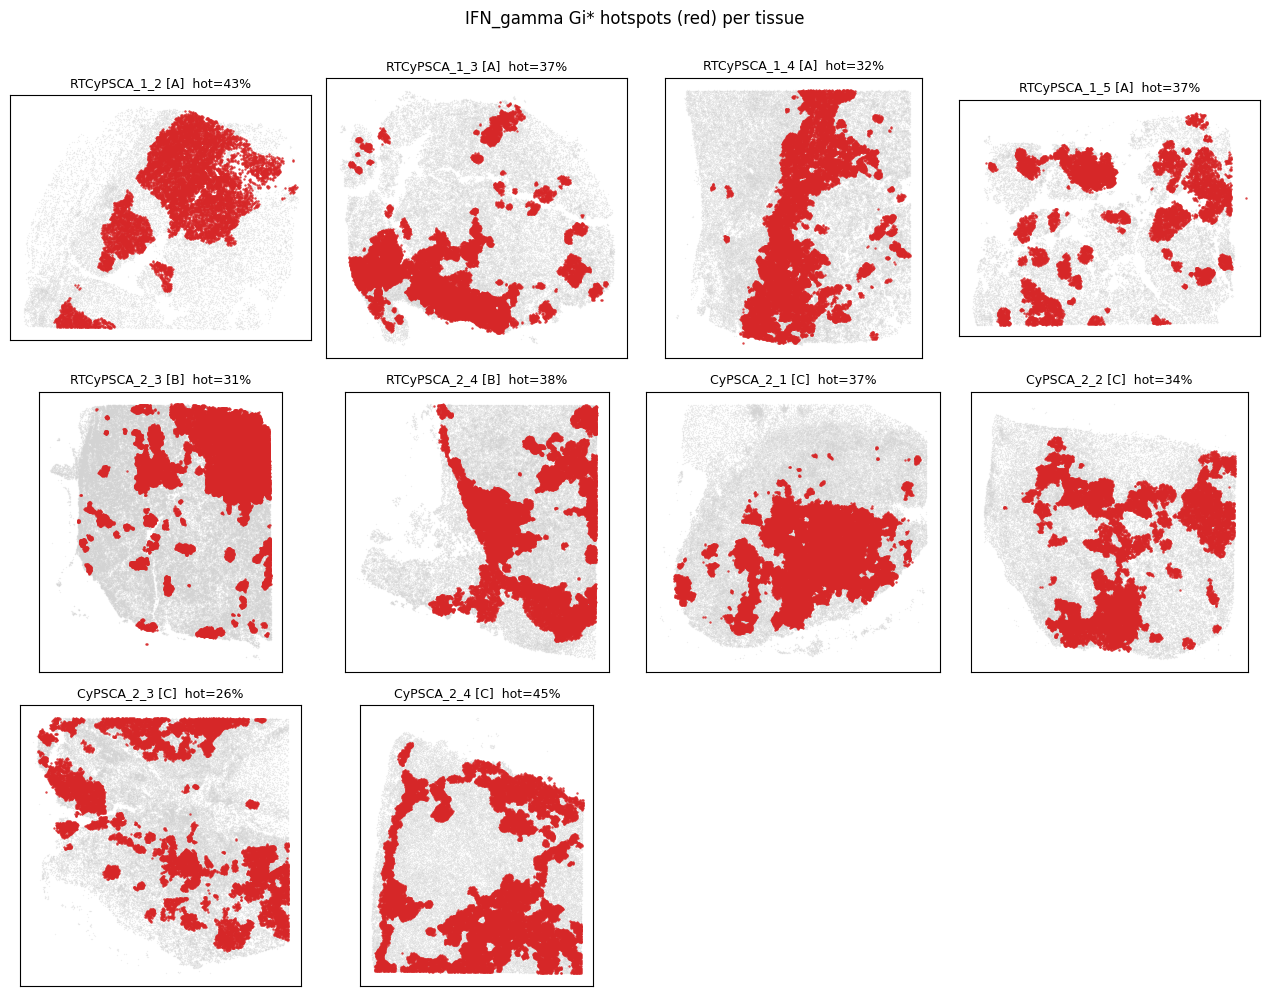

saved hotspot maps -> /coh_labs/yunroseli/Jona/CAR-T/results/ifng_hotspot_featureset/figures


In [13]:
import matplotlib.pyplot as plt

fig_dir = out_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
GTAG = {"A_RT_primary": "A", "B_RT_secondary": "B", "C_noRT_secondary": "C"}

def _hotspot_panel(ax, tissue):
    tmask, coords_um, _ = gu.get_tissue_coords_um(
        adata, sdata, tissue, TISSUE_COL, MICRONS_PER_PIXEL, APPLY_HIRES_SCALE)
    hot = adata.obs["IFN_gamma_score_hotspot"].astype(bool).values[tmask]
    ax.scatter(coords_um[~hot, 0], coords_um[~hot, 1], s=1, c="lightgray",
               alpha=0.35, linewidths=0, rasterized=True)
    ax.scatter(coords_um[hot, 0], coords_um[hot, 1], s=3, c="#d62728",
               alpha=0.85, linewidths=0, rasterized=True)
    ax.set_title(f"{tissue} [{GTAG.get(assign_group(tissue), '?')}]  hot={hot.mean()*100:.0f}%",
                 fontsize=9)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([])

# combined grid (displayed + saved)
ncols = 4
nrows = int(np.ceil(len(TISSUES_PRESENT) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.3 * nrows), squeeze=False)
for ax, t in zip(axes.ravel(), TISSUES_PRESENT):
    _hotspot_panel(ax, t)
for ax in axes.ravel()[len(TISSUES_PRESENT):]:
    ax.axis("off")
fig.suptitle("IFN_gamma Gi* hotspots (red) per tissue", y=1.002, fontsize=12)
fig.tight_layout()
fig.savefig(fig_dir / "ifng_hotspots_by_tissue.png", dpi=150, bbox_inches="tight")
plt.show()

# per-tissue PNGs
for t in TISSUES_PRESENT:
    f, ax = plt.subplots(figsize=(5, 5))
    _hotspot_panel(ax, t)
    f.tight_layout()
    f.savefig(fig_dir / f"ifng_hotspot_{t}.png", dpi=150, bbox_inches="tight")
    plt.close(f)
print("saved hotspot maps ->", fig_dir)


## 6. Recompute ligand–receptor scores per tissue (LIANA+)

LR scores are spatial, so they're computed **per tissue** on the full tissue (neighbourhoods
include non-hotspot neighbours), then we keep the hotspot rows. The LR-pair set differs per
tissue (the `nz_prop` filter), so we take the **union** of pairs and fill absent ones with NaN.
Reuses the `Clustering/LAINA+.ipynb` recipe; `bandwidth` is the per-tissue median distance to the
6th nearest neighbour.

In [8]:
lr_frames = {}
for t in TISSUES_PRESENT:
    sub = adata[adata.obs[TISSUE_COL].astype(str) == t].copy()
    if sub.n_obs < MIN_CELLS:
        continue
    coords = np.asarray(sub.obsm["spatial"], dtype=float)
    nbrs = NearestNeighbors(n_neighbors=7).fit(coords)         # 6 neighbours + self
    bw = float(np.median(nbrs.kneighbors(coords)[0][:, 6]))
    try:
        li.ut.spatial_neighbors(sub, bandwidth=bw, cutoff=LR_CUTOFF, kernel=LR_KERNEL, set_diag=True)
        lrd = li.mt.bivariate(sub, resource_name=LR_RESOURCE, local_name=LR_LOCAL,
                              global_name=LR_GLOBAL, n_perms=LR_N_PERMS, mask_negatives=False,
                              add_categories=False, nz_prop=LR_NZ_PROP, use_raw=False, verbose=False)
        Xlr = lrd.X.toarray() if sp.issparse(lrd.X) else np.asarray(lrd.X)
        lr_frames[t] = pd.DataFrame(Xlr, index=lrd.obs_names.astype(str),
                                    columns=lrd.var_names.astype(str))
        print(f"  {t}: bw={bw:.1f}, {lrd.n_vars} LR pairs, {sub.n_obs:,} cells")
    except Exception as e:
        print(f"  {t}: LR FAILED -> {type(e).__name__}: {e}")

lr_all = pd.concat(lr_frames.values(), axis=0)          # rows = all tissue cells, cols = union of pairs
lr_hot = lr_all.reindex(sel_names.astype(str))          # keep hotspot cells, aligned order
lr_features = list(lr_hot.columns)
print(f"\nLR matrix: {lr_hot.shape[0]:,} hotspot cells x {len(lr_features)} LR pairs "
      f"(NaN frac {np.isnan(lr_hot.values).mean():.3f})")


  RTCyPSCA_1_2: bw=53.5, 400 LR pairs, 28,637 cells
  RTCyPSCA_1_3: bw=46.7, 658 LR pairs, 57,620 cells
  RTCyPSCA_1_4: bw=37.2, 173 LR pairs, 69,639 cells
  RTCyPSCA_1_5: bw=53.7, 526 LR pairs, 35,860 cells
  RTCyPSCA_2_3: bw=38.5, 336 LR pairs, 112,486 cells
  RTCyPSCA_2_4: bw=40.7, 424 LR pairs, 65,157 cells
  CyPSCA_2_1: bw=36.7, 288 LR pairs, 86,108 cells
  CyPSCA_2_2: bw=47.7, 373 LR pairs, 61,384 cells
  CyPSCA_2_3: bw=43.1, 249 LR pairs, 67,945 cells
  CyPSCA_2_4: bw=38.9, 585 LR pairs, 54,121 cells

LR matrix: 224,088 hotspot cells x 716 LR pairs (NaN frac 0.453)


## 7. Assemble the combined AnnData

In [9]:
ifng = adata[sel_names].copy()                          # X = lognorm genes, var = genes
# trim obs to the metadata + categoricals + spatial-context we want to carry
ctx_cols = [c for c in OPTIONAL_CTX_COLS if c in ifng.obs.columns]
keep_obs = [TISSUE_COL, CELL_TYPE_COL, CC_COL, "IFN_gamma_score",
            "IFN_gamma_score_GiZ"] + ctx_cols
ifng.obs = ifng.obs[keep_obs].copy()
ifng.obs["group"] = pd.Categorical(grp_per_cell[sel].values, categories=GROUP_ORDER, ordered=True)
ifng.obs["cell_id"] = ifng.obs_names.astype(str)

# LR block -> obsm (rows already aligned to ifng.obs_names)
ifng.obsm["lr"] = lr_hot.loc[ifng.obs_names.astype(str)].values
ifng.uns["lr_features"] = lr_features
ifng.uns["ifn_gamma_genes"] = ifn_genes
ifng.uns["feature_blocks"] = {
    "gene": "adata.X (lognorm) -> ifng.X / var_names",
    "ct":   f"obs['{CELL_TYPE_COL}'] cell type (categorical)",
    "cc":   f"obs['{CC_COL}'] CellCharter niche (categorical)",
    "lr":   "obsm['lr'] per-tissue LIANA+ local cosine, cols = uns['lr_features']",
    "spatialctx": "IFN_gamma_score, IFN_gamma_score_GiZ" + (", " + ", ".join(ctx_cols) if ctx_cols else ""),
}
print(ifng)
print("LR in obsm:", ifng.obsm["lr"].shape)


AnnData object with n_obs × n_vars = 224088 × 19059
    obs: 'tissue', 'c2l_permissive', 'X_cc_2', 'IFN_gamma_score', 'IFN_gamma_score_GiZ', 'group', 'cell_id'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'condition_colors', 'log1p', 'spatialdata_attrs', 'spatial_neighbors', 'normalization', 'lr_features', 'ifn_gamma_genes', 'feature_blocks'
    obsm: 'X_cc_1', 'X_cc_012', 'c2l_means', 'X_cc_2', 'spatial', 'X_scVI', 'X_cc_01', 'c2l_q95', 'X_cc_0', 'c2l_q05', 'lr'
    layers: 'counts'
    obsp: 'spatial_distances', 'spatial_connectivities'
LR in obsm: (224088, 716)


## 8. Flat model-ready table + data dictionary

In [10]:
# gene block
Xg = ifng.X.toarray() if sp.issparse(ifng.X) else np.asarray(ifng.X)
genes_df = pd.DataFrame(Xg, index=ifng.obs_names.astype(str),
                        columns=[f"gene_{g}" for g in ifng.var_names.astype(str)])
# LR block
lr_df = pd.DataFrame(ifng.obsm["lr"], index=ifng.obs_names.astype(str),
                     columns=[f"lr_{p}" for p in lr_features])
# categoricals (left raw; modeler one-hots)
cat_df = pd.DataFrame({
    "ct_celltype": ifng.obs[CELL_TYPE_COL].astype(str).values,
    "cc_cluster":  ifng.obs[CC_COL].astype(str).values,
}, index=ifng.obs_names.astype(str))
# spatial-context block
ctx_df = ifng.obs[["IFN_gamma_score", "IFN_gamma_score_GiZ"] + ctx_cols].copy()
ctx_df.columns = [f"spatialctx_{c}" for c in ctx_df.columns]
ctx_df.index = ifng.obs_names.astype(str)
# labels
meta_df = pd.DataFrame({"cell_id": ifng.obs_names.astype(str),
                        "group": ifng.obs["group"].astype(str).values,
                        "tissue": ifng.obs[TISSUE_COL].astype(str).values},
                       index=ifng.obs_names.astype(str))

flat = pd.concat([meta_df, cat_df, ctx_df, lr_df, genes_df], axis=1)
print("flat feature table:", flat.shape)

# data dictionary with a selection-adjacent (leakage) flag
ifn_gene_cols = {f"gene_{g}" for g in ifn_genes}
def _row(col):
    if col in ("cell_id", "group", "tissue"):
        block, dtype, scale, sel_adj = "meta", "id/label", "n/a", False
    elif col.startswith("gene_"):
        block, dtype, scale = "gene", "float", "lognorm"
        sel_adj = col in ifn_gene_cols
    elif col.startswith("lr_"):
        block, dtype, scale, sel_adj = "lr", "float", "local_cosine[0-1]", False
    elif col.startswith("ct_"):
        block, dtype, scale, sel_adj = "celltype", "categorical", "n/a", False
    elif col.startswith("cc_"):
        block, dtype, scale, sel_adj = "cellcharter", "categorical", "n/a", False
    elif col.startswith("spatialctx_"):
        block, dtype, scale = "spatial_context", "float", "score"
        sel_adj = "IFN_gamma" in col
    else:
        block, dtype, scale, sel_adj = "other", "?", "?", False
    return {"feature": col, "block": block, "dtype": dtype, "scale": scale,
            "selection_adjacent": sel_adj}

feature_dictionary = pd.DataFrame([_row(c) for c in flat.columns])
print(feature_dictionary["block"].value_counts())
print("selection_adjacent features:", int(feature_dictionary["selection_adjacent"].sum()))


flat feature table: (224088, 19782)
block
gene               19059
lr                   716
meta                   3
spatial_context        2
celltype               1
cellcharter            1
Name: count, dtype: int64
selection_adjacent features: 182


## 9. Write README + save all artifacts

In [11]:
readme_lines = [
    "# IFN_gamma hotspot feature set",
    "",
    "Cells = IFN_gamma Gi* hotspot cells (z>0 & FDR q_hot<0.05) across three groups.",
    "Goal: Lasso / Random Forest feature selection of features that",
    "distinguish the groups. ",
    "",
    "## Files",
    "- `ifng_hotspot_featureset.h5ad` : AnnData. X=lognorm genes; obsm['lr']=LR matrix",
    "  (cols in uns['lr_features']); obs has group, tissue, cell type, cluster_cellcharter,",
    "  IFN_gamma_score(+GiZ); obsm['spatial']=coords.",
    "- `ifng_hotspot_featuretable.parquet` : wide cells x features, model-ready.",
    "- `feature_dictionary.csv` : feature, block, dtype, scale, selection_adjacent.",
    "",
    "## Columns / blocks (parquet)",
    "- `gene_*`  : lognorm expression (continuous)",
    "- `lr_*`    : LIANA+ local cosine ligand-receptor scores, per-tissue (continuous, spatial)",
    "- `ct_celltype` : c2l_permissive cell type (categorical -> you one-hot)",
    "- `cc_cluster`  : CellCharter niche (categorical -> you one-hot)",
    "- `spatialctx_*`: IFN_gamma score + Gi* z (continuous, spatial context)",
    "- `group` : TARGET (A_RT_primary / B_RT_secondary / C_noRT_secondary)",
    "- `tissue`: biological replicate / batch id  (USE THIS FOR CV — see below)",
    "- `cell_id`: index",
    "",
    "## CRITICAL: pseudoreplication",
    "Only 2-4 tissues per group but tens of thousands of cells. Cells within a tissue are NOT",
    "independent. A classifier can separate groups by learning TISSUE/BATCH signatures, not",
    "condition biology, and report near-perfect accuracy + misleading feature importances.",
    "REQUIRED: cross-validate by tissue (sklearn GroupKFold / LeaveOneGroupOut, groups=tissue),",
    "i.e. leave-one-tissue-out. Check selected features are consistent across replicate tissues.",
    "Consider a per-tissue pseudobulk sanity check.",
    "",
    "## Selection leakage",
    "Cells were selected on IFN_gamma hotspot status. Features flagged selection_adjacent=True in",
    "the dictionary (IFN_gamma score + IFN-gamma genes) can be trivially predictive / circular.",
    "Consider dropping them, or interpret with care.",
    "",
    "## Method notes (Lasso vs Random Forest)",
    "- Lasso (L1 logistic): sparse, interpretable coefficients, fast; but linear, unstable among",
    "  correlated genes/LR, and scale-sensitive -> STANDARDIZE continuous blocks (gene_/lr_/",
    "  spatialctx_), leave one-hot dummies unscaled.",
    "- Random Forest: nonlinear, interactions, mixed feature types, scale-robust, gives",
    "  importances; but importance is biased toward high-cardinality continuous features",
    "  (genes/LR) over binary dummies, overfits with few independent samples, and importances are",
    "  unstable across correlated features -> use permutation_importance + repeated/grouped CV.",
    "- Both: high collinearity (genes & LR) -> consider stability selection / elastic-net.",
    "",
    "## NaNs",
    "`lr_*` may be NaN where a pair did not pass the per-tissue nz_prop filter. Impute (e.g. 0)",
    "or drop high-NaN LR columns before modeling.",
    "",
    "## Provenance",
    "LR via LIANA+ li.mt.bivariate(resource='mouseconsensus', local='cosine'); note the resource",
    "is documented as using human-cased gene symbols. Built from zarr 1_C2l_annotated_CC.",
]
(out_dir / "README.md").write_text("\n".join(readme_lines))

ifng.write_h5ad(out_dir / "ifng_hotspot_featureset.h5ad")
flat.to_parquet(out_dir / "ifng_hotspot_featuretable.parquet", index=False)
feature_dictionary.to_csv(out_dir / "feature_dictionary.csv", index=False)
sel_meta.reset_index().to_csv(out_dir / "selected_cells_group_map.csv", index=False)

print("Saved to:", out_dir)
for f in sorted(out_dir.iterdir()):
    print("  ", f.name)


Saved to: /coh_labs/yunroseli/Jona/CAR-T/results/ifng_hotspot_featureset
   README.md
   feature_dictionary.csv
   ifng_hotspot_featureset.h5ad
   ifng_hotspot_featuretable.parquet
   selected_cells_group_map.csv


## 10. Verification

In [12]:
# 1) alignment: every block on the same cell-ID order, no dup/drop
assert list(genes_df.index) == list(ifng.obs_names.astype(str))
assert list(lr_df.index) == list(ifng.obs_names.astype(str))
assert flat["cell_id"].is_unique and len(flat) == ifng.n_obs
# 2) LR rows match hotspot cells 1:1
assert ifng.obsm["lr"].shape == (ifng.n_obs, len(lr_features))
# 3) dictionary covers every parquet column
assert set(feature_dictionary["feature"]) == set(flat.columns)
# 4) parquet round-trips
rt = pd.read_parquet(out_dir / "ifng_hotspot_featuretable.parquet")
assert rt.shape == flat.shape
# 5) spot-check a known LR pair if present
for probe in ("Spp1^Cd44", "Fn1^Nt5e", "Apoe^Lrp1"):
    if f"lr_{probe}" in flat.columns:
        s = flat[f"lr_{probe}"]
        print(f"LR probe lr_{probe}: non-NaN={s.notna().sum():,}, std={np.nanstd(s):.3f}")
        break

print("\ngroup x tissue cell counts (pseudoreplication structure):")
print(flat.groupby(["group", "tissue"]).size())
print("\nfeature blocks:")
print(feature_dictionary["block"].value_counts())
print("\nALL CHECKS PASSED")


LR probe lr_Spp1^Cd44: non-NaN=224,088, std=0.228

group x tissue cell counts (pseudoreplication structure):
group             tissue      
A_RT_primary      RTCyPSCA_1_2    12305
                  RTCyPSCA_1_3    21310
                  RTCyPSCA_1_4    22306
                  RTCyPSCA_1_5    13312
B_RT_secondary    RTCyPSCA_2_3    35264
                  RTCyPSCA_2_4    24762
C_noRT_secondary  CyPSCA_2_1      31686
                  CyPSCA_2_2      20764
                  CyPSCA_2_3      17835
                  CyPSCA_2_4      24544
dtype: int64

feature blocks:
block
gene               19059
lr                   716
meta                   3
spatial_context        2
celltype               1
cellcharter            1
Name: count, dtype: int64

ALL CHECKS PASSED
